# Fast Density Clustering (FDC) — Algorithm Walkthrough

**Author:** Alexandre Day  
**Date:** March 1, 2026  
**Purpose:** Explore the current state of the FDC algorithm — decompose each step, visualize intermediate results, and identify areas for improvement.

### How to run

```bash
cd fast_density_clustering
uv pip install -e ".[dev,plotting]"
# Open in Jupyter or VS Code and run all cells
```

---

## Overview

FDC clusters data by:
1. **Estimating density** at every point via kernel density estimation (KDE)
2. **Building a density graph** — each point links to its nearest neighbor with higher density
3. **Identifying cluster centers** — points that are local density maxima within their neighborhood
4. **Assigning labels** — follow the density graph from each point uphill to its center
5. **Merging unstable clusters** — using a noise threshold $\eta$ to combine spurious fragments

Complexity: $O(n \log n)$ time, $O(n)$ memory.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KernelDensity
from sklearn.metrics import adjusted_rand_score

from fdc.density_estimation import KDE
from fdc.fdc import index_greater, assign_cluster, check_cluster_stability, FDC

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

In [2]:
# Load the test datasets
np.random.seed(42)
n_samples = 1500

data = {
    'circles': datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05),
    'moons':   datasets.make_moons(n_samples=n_samples, noise=0.05),
    'blobs':   datasets.make_blobs(n_samples=n_samples, random_state=8),
}

# Normalize all datasets
for name in data:
    X, y = data[name]
    data[name] = (StandardScaler().fit_transform(X), y)

# Pick a dataset for the walkthrough
DATASET = 'circles'
X, y_true = data[DATASET]
print(f'Dataset: {DATASET}, n={X.shape[0]}, true clusters={len(np.unique(y_true))}')

Dataset: circles, n=1500, true clusters=2


---

## Step 1 — k-Nearest Neighbors

Build a kd-tree and find the $k$ nearest neighbors for every point, where $k$ = `nh_size`.

This defines the **local neighborhood** each point can see. The choice of $k$ is critical:

| Formula | $n{=}1500$ | $n{=}10000$ |
|---------|-----------|------------|
| Old (2017): $k = n/100$ | 15 | 100 |
| Current: $k = 25 \log_{10}(n)$ | 79 | 100 |

For ring-shaped data, a large $k$ creates **bridges** between the inner and outer ring.

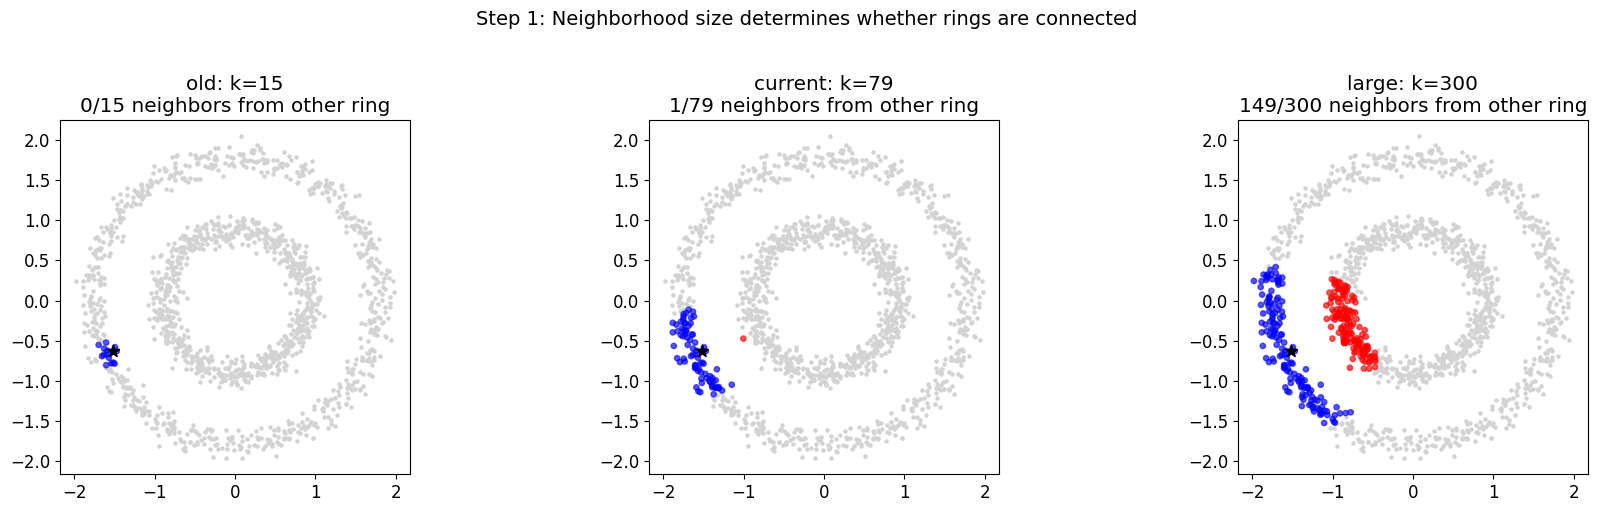

In [3]:
nh_size = 79  # current default for n=1500

nbrs = NearestNeighbors(n_neighbors=nh_size, algorithm='kd_tree').fit(X)
nn_dist, nn_list = nbrs.kneighbors(X)

# Visualize: for one point on the outer ring, show its neighborhood
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nh, label) in zip(axes, [(15, 'old: k=15'), (79, 'current: k=79'), (300, 'large: k=300')]):
    nbrs_tmp = NearestNeighbors(n_neighbors=nh, algorithm='kd_tree').fit(X)
    _, nn_tmp = nbrs_tmp.kneighbors(X)
    
    # Pick a point on the outer ring (label=0)
    outer_pts = np.where(y_true == 0)[0]
    probe = outer_pts[0]
    neighbors = nn_tmp[probe]
    
    ax.scatter(X[:, 0], X[:, 1], c='lightgray', s=5, zorder=1)
    ax.scatter(X[neighbors, 0], X[neighbors, 1], c=['blue' if y_true[n]==0 else 'red' for n in neighbors], 
              s=15, zorder=2, alpha=0.6)
    ax.scatter(X[probe, 0], X[probe, 1], c='black', s=80, marker='*', zorder=3)
    
    # Count cross-ring neighbors
    cross = sum(y_true[n] != y_true[probe] for n in neighbors)
    ax.set_title(f'{label}\n{cross}/{nh} neighbors from other ring')
    ax.set_aspect('equal')

fig.suptitle('Step 1: Neighborhood size determines whether rings are connected', fontsize=14, y=1.02)
plt.tight_layout()

---

## Step 2 — Kernel Density Estimation

Fit a KDE model and estimate the log-density $\rho(x_i)$ at every point.

The bandwidth $h$ is found by **maximum-likelihood cross-validation**:

$$h^* = \arg\max_h \; \sum_{x \in X_{\text{test}}} \log \hat{f}_h(x)$$

where $\hat{f}_h$ is the KDE fitted on $X_{\text{train}}$, and the search is over $[h_{\min}, 0.2 \cdot h_{\max}]$.

The bounds are estimated from nearest-neighbor distances:

$$h_{\min} = \sqrt{\frac{\langle d_{\text{NN}}^2 \rangle}{D}}, \qquad h_{\max} = \sqrt{\frac{\langle d_{\text{typical}}^2 \rangle}{D}}$$

[kde] Minimum bound = 0.0286 	 Rough estimate of h = 0.2859 	 Maximum bound = 1.3543
[kde] Bandwidth tolerance (xtol) set to precision of minimum bound : 0.01000 
[kde] Found log-likelihood maximum in 7 evaluations, h = 0.06394
Bandwidth: 0.06394


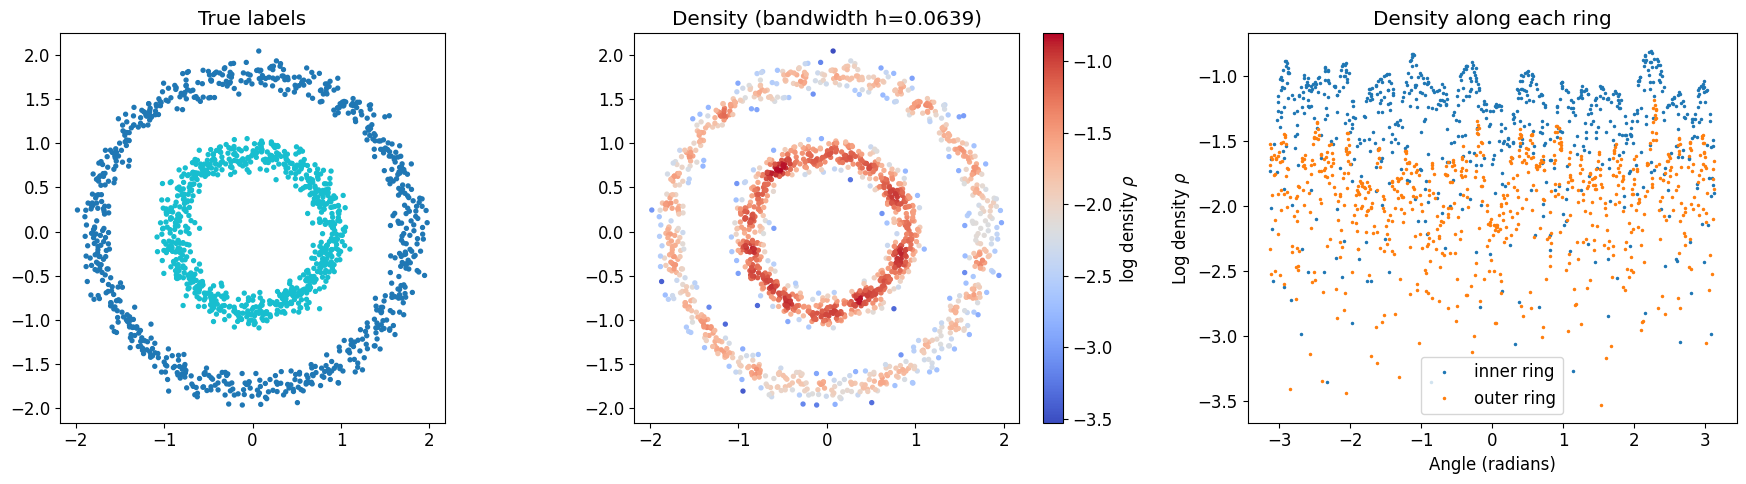

In [4]:
kde = KDE(bandwidth=None)
kde.nn_dist = nn_dist
kde.fit(X)
rho = kde.evaluate_density(X)

print(f'Bandwidth: {kde.bandwidth:.5f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: true labels
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=8)
ax.set_title('True labels')
ax.set_aspect('equal')

# Panel 2: density map
ax = axes[1]
sc = ax.scatter(X[:, 0], X[:, 1], c=rho, cmap='coolwarm', s=8)
plt.colorbar(sc, ax=ax, label='log density $\\rho$')
ax.set_title(f'Density (bandwidth h={kde.bandwidth:.4f})')
ax.set_aspect('equal')

# Panel 3: density along each ring (by angle)
ax = axes[2]
for label, name, color in [(1, 'inner', 'tab:blue'), (0, 'outer', 'tab:orange')]:
    mask = y_true == label
    angles = np.arctan2(X[mask, 1], X[mask, 0])
    order = np.argsort(angles)
    ax.plot(angles[order], rho[mask][order], '.', ms=3, color=color, label=f'{name} ring')

ax.set_xlabel('Angle (radians)')
ax.set_ylabel('Log density $\\rho$')
ax.set_title('Density along each ring')
ax.legend()

plt.tight_layout()

---

## Step 3 — Density Graph Construction (`compute_delta`)

For each point $x_i$, find the **nearest neighbor with higher density** within its $k$-NN neighborhood:

$$\text{nn\_delta}(i) = \arg\min_{j \in \text{kNN}(i)} \|x_i - x_j\| \quad \text{s.t.} \quad \rho(x_j) > \rho(x_i) + \epsilon$$

$$\delta(i) = \|x_i - x_{\text{nn\_delta}(i)}\|$$

If no such neighbor exists (i.e., $x_i$ has the highest density in its neighborhood), then $\delta(i) = \delta_{\max}$ and $x_i$ is a **potential cluster center**.

Center detection criterion: $\delta(i) > 0.999 \cdot \delta_{\max}$

The resulting **density graph** is a directed forest: each point has one outgoing edge (to its higher-density neighbor), and the roots are the cluster centers.

In [5]:
n_sample = X.shape[0]
n_feature = X.shape[1]

maxdist = np.linalg.norm([np.max(X[:, i]) - np.min(X[:, i]) for i in range(n_feature)])
delta = maxdist * np.ones(n_sample, dtype=float)
nn_delta = np.ones(n_sample, dtype=int)
density_graph = [[] for _ in range(n_sample)]

for i in range(n_sample):
    idx = index_greater(rho[nn_list[i]])
    if idx:
        density_graph[nn_list[i, idx]].append(i)
        nn_delta[i] = nn_list[i, idx]
        delta[i] = nn_dist[i, idx]
    else:
        nn_delta[i] = -1

idx_centers = np.where(delta > 0.999 * maxdist)[0]

print(f'Potential centers found: {len(idx_centers)}')
print(f'  On inner ring: {sum(y_true[c] == 1 for c in idx_centers)}')
print(f'  On outer ring: {sum(y_true[c] == 0 for c in idx_centers)}')

Potential centers found: 18
  On inner ring: 7
  On outer ring: 11


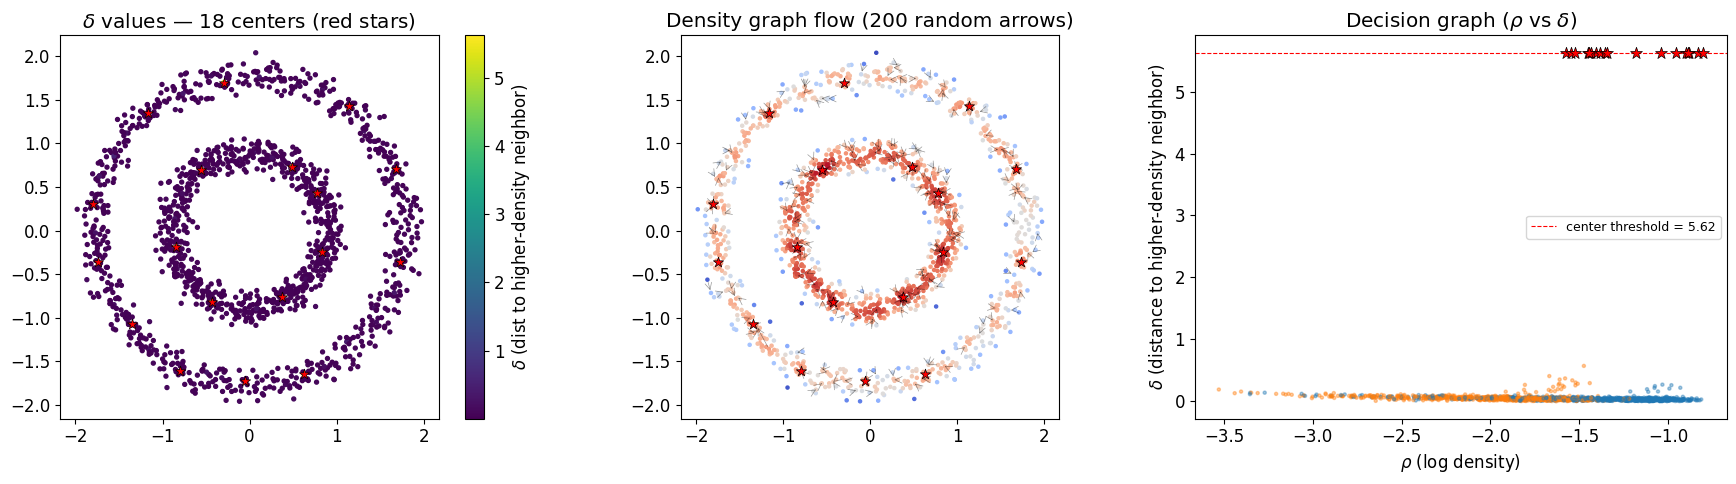

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: delta values
ax = axes[0]
sc = ax.scatter(X[:, 0], X[:, 1], c=np.clip(delta, 0, np.percentile(delta, 99)),
               cmap='viridis', s=8)
ax.scatter(X[idx_centers, 0], X[idx_centers, 1], c='red', s=60, marker='*', 
          edgecolors='black', linewidth=0.5, zorder=5)
plt.colorbar(sc, ax=ax, label='$\\delta$ (dist to higher-density neighbor)')
ax.set_title(f'$\\delta$ values — {len(idx_centers)} centers (red stars)')
ax.set_aspect('equal')

# Panel 2: density graph flow (subsample arrows for clarity)
ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], c=rho, cmap='coolwarm', s=5, zorder=1)
# Draw arrows for a random subset of points
rng = np.random.default_rng(42)
sample = rng.choice(n_sample, size=200, replace=False)
for i in sample:
    if nn_delta[i] != -1:
        j = nn_delta[i]
        dx, dy = X[j, 0] - X[i, 0], X[j, 1] - X[i, 1]
        ax.annotate('', xy=(X[j, 0], X[j, 1]), xytext=(X[i, 0], X[i, 1]),
                   arrowprops=dict(arrowstyle='->', color='black', lw=0.5, alpha=0.4))
ax.scatter(X[idx_centers, 0], X[idx_centers, 1], c='red', s=60, marker='*',
          edgecolors='black', linewidth=0.5, zorder=5)
ax.set_title('Density graph flow (200 random arrows)')
ax.set_aspect('equal')

# Panel 3: decision graph (rho vs delta)
ax = axes[2]
ax.scatter(rho, delta, s=5, c=['tab:blue' if y_true[i]==1 else 'tab:orange' for i in range(n_sample)], alpha=0.4)
ax.scatter(rho[idx_centers], delta[idx_centers], c='red', s=80, marker='*',
          edgecolors='black', linewidth=0.5, zorder=5)
ax.set_xlabel('$\\rho$ (log density)')
ax.set_ylabel('$\\delta$ (distance to higher-density neighbor)')
ax.set_title('Decision graph ($\\rho$ vs $\\delta$)')
ax.axhline(0.999 * maxdist, color='red', ls='--', lw=0.8, label=f'center threshold = {0.999*maxdist:.2f}')
ax.legend(fontsize=9)

plt.tight_layout()

---

## Step 4 — Cluster Assignment

Traverse the density graph (a directed forest) from each center. Every point reachable from center $c$ gets label $c$.

This is a recursive DFS: `assign_cluster_deep(density_graph[c], label=c)`.

Clusters before merging: 18, ARI = 0.1240


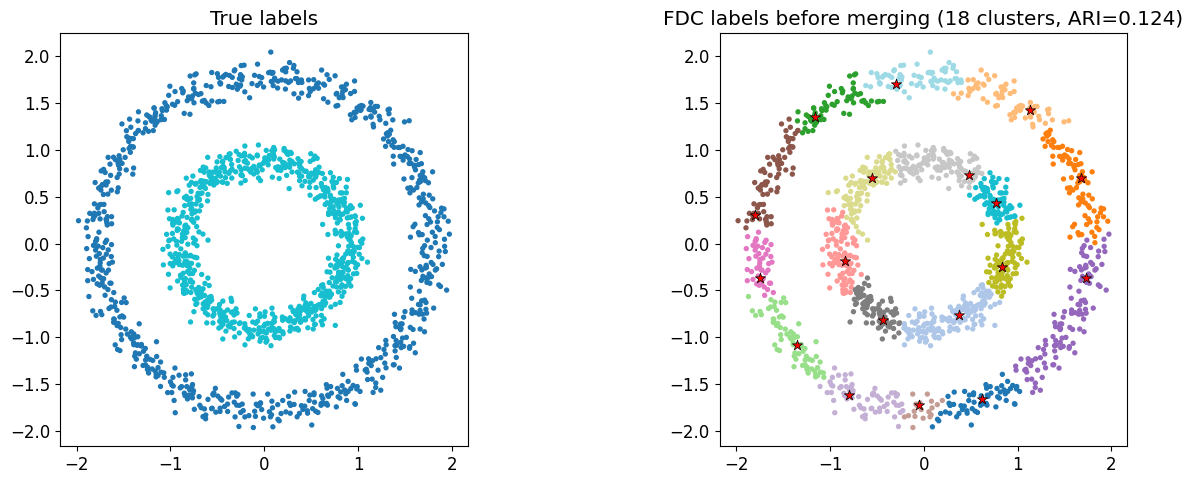

In [7]:
cluster_label = assign_cluster(idx_centers, nn_delta, density_graph)

n_clusters = len(np.unique(cluster_label[cluster_label >= 0]))
ari = adjusted_rand_score(y_true, cluster_label)
print(f'Clusters before merging: {n_clusters}, ARI = {ari:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', s=8)
ax.set_title('True labels')
ax.set_aspect('equal')

ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], c=cluster_label, cmap='tab20', s=8)
ax.scatter(X[idx_centers, 0], X[idx_centers, 1], c='red', s=60, marker='*',
          edgecolors='black', linewidth=0.5, zorder=5)
ax.set_title(f'FDC labels before merging ({n_clusters} clusters, ARI={ari:.3f})')
ax.set_aspect('equal')

plt.tight_layout()

---

## Step 5 — Cluster Merging (`check_cluster_stability`)

For each center $c$ with density $\rho_c$, expand an **$\eta$-neighborhood**:

$$\mathcal{N}_\eta(c) = \{ x_j : \rho(x_j) > \rho_c - \eta, \; x_j \text{ is density-reachable from } c \}$$

The reachability is computed by `find_NH_tree_search` — a BFS that expands along the $k$-NN graph, staying above the density threshold $\rho_c - \eta$.

If a center's $\eta$-neighborhood contains a point belonging to a **higher-density center**, the current center is deemed a **false positive** and merged into the higher-density cluster.

This repeats until no more merges occur. The process runs twice:
1. At $\eta = 0$ — merge overlapping minimal clusters
2. At user-specified $\eta$ — merge "noisy" clusters

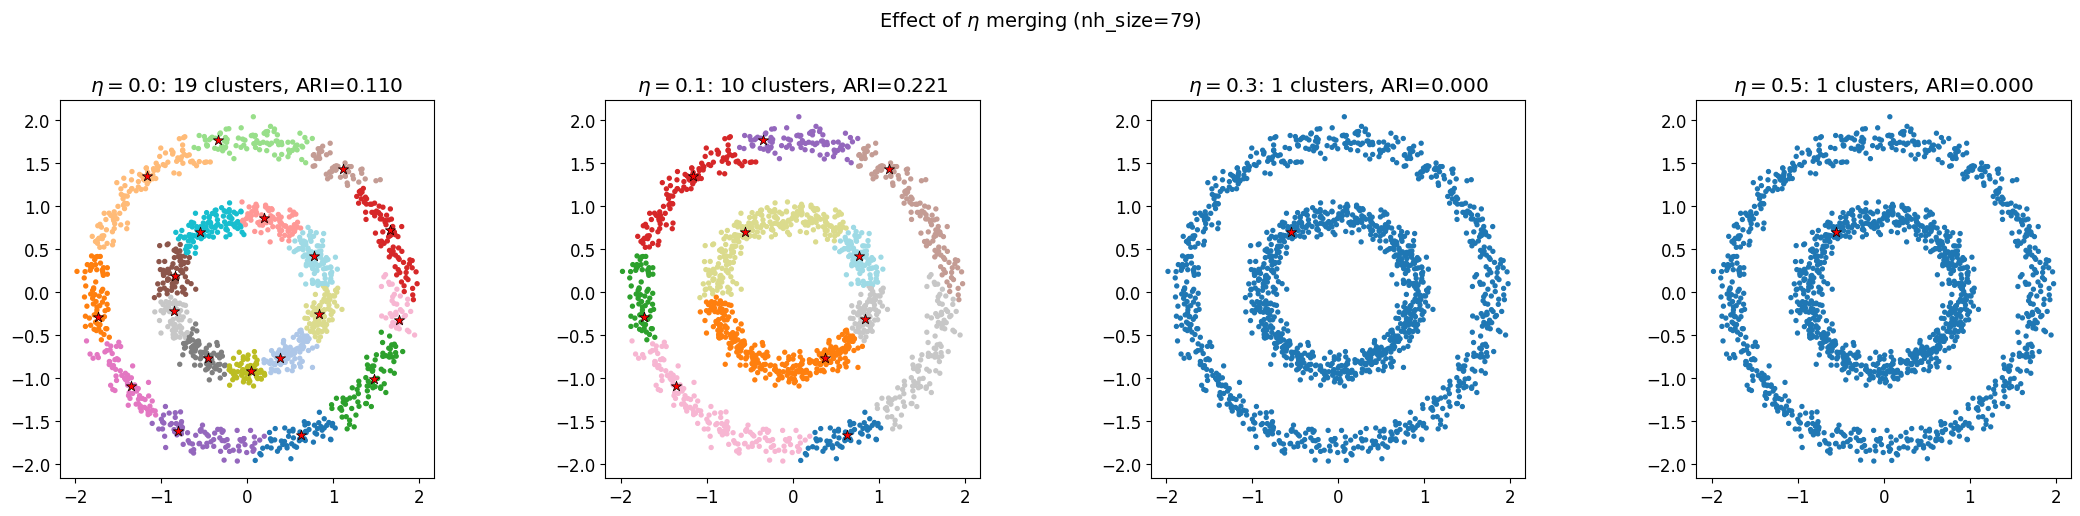

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

eta_values = [0.0, 0.1, 0.3, 0.5]

for ax, eta in zip(axes, eta_values):
    m = FDC(eta=eta, nh_size=nh_size, verbose=0)
    m.fit(X)
    nc = len(np.unique(m.cluster_label))
    ari = adjusted_rand_score(y_true, m.cluster_label)
    
    ax.scatter(X[:, 0], X[:, 1], c=m.cluster_label, cmap='tab20', s=8)
    ax.scatter(X[m.idx_centers, 0], X[m.idx_centers, 1], c='red', s=60, marker='*',
              edgecolors='black', linewidth=0.5, zorder=5)
    ax.set_title(f'$\\eta={eta}$: {nc} clusters, ARI={ari:.3f}')
    ax.set_aspect('equal')

fig.suptitle(f'Effect of $\\eta$ merging (nh_size={nh_size})', fontsize=14, y=1.02)
plt.tight_layout()

---

## Analysis: Why Circles Fail

The density along each ring is **nearly uniform** (coefficient of variation ~15–20%). This means:

1. **Many local maxima per ring** — random density fluctuations create ~9 spurious centers per ring
2. **Short gradient chains** — each point flows to a nearby neighbor (avg ~7 hops), not to a global ring maximum
3. **Cross-ring bridges** — with `nh_size=79`, some neighborhoods span from the outer ring to the inner ring

When $\eta$-merging tries to combine the fragments:
- Small $\eta$ leaves too many fragments on each ring
- Large $\eta$ merges BOTH rings into one cluster (because the cross-ring bridges let the $\eta$-neighborhood leak across)

There is **no $\eta$ that merges fragments within each ring without also merging across rings** at `nh_size=79`.

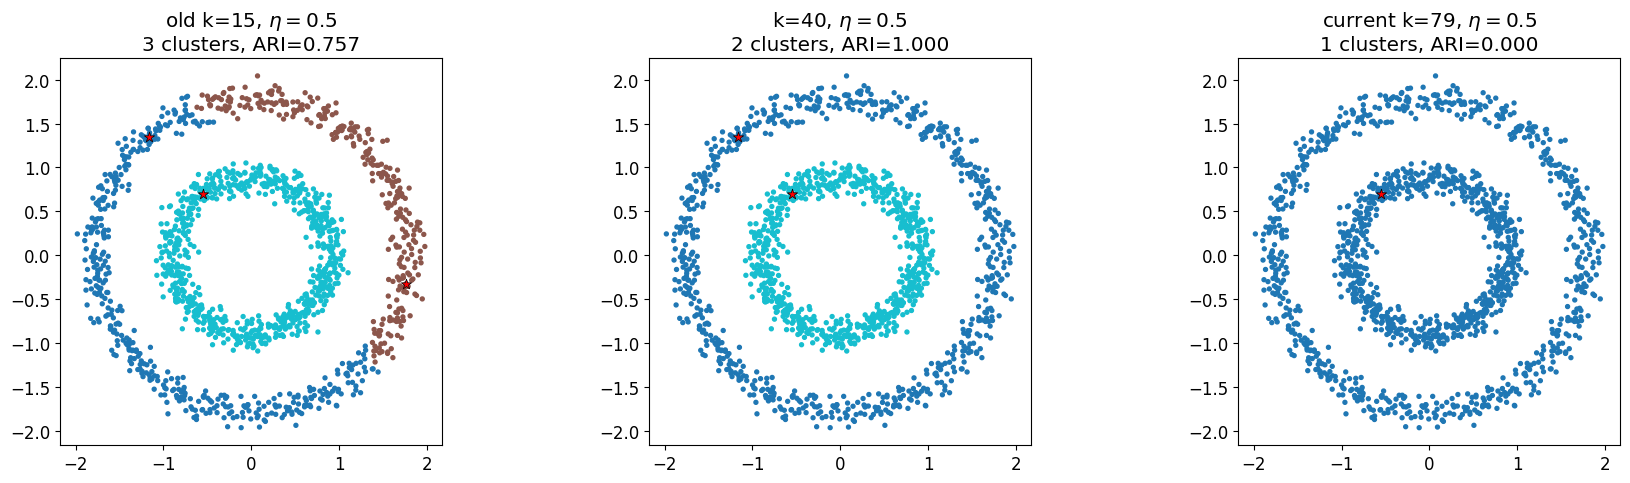

In [9]:
# Demonstrate: with old nh_size=15, eta=0.5 separates the rings correctly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (15,  0.5, 'old k=15, $\\eta=0.5$'),
    (40,  0.5, 'k=40, $\\eta=0.5$'),
    (79,  0.5, 'current k=79, $\\eta=0.5$'),
]

for ax, (nh, eta, title) in zip(axes, configs):
    m = FDC(eta=eta, nh_size=nh, verbose=0)
    m.fit(X)
    nc = len(np.unique(m.cluster_label))
    ari = adjusted_rand_score(y_true, m.cluster_label)
    
    ax.scatter(X[:, 0], X[:, 1], c=m.cluster_label, cmap='tab10', s=8)
    ax.scatter(X[m.idx_centers, 0], X[m.idx_centers, 1], c='red', s=60, marker='*',
              edgecolors='black', linewidth=0.5, zorder=5)
    ax.set_title(f'{title}\n{nc} clusters, ARI={ari:.3f}')
    ax.set_aspect('equal')

plt.tight_layout()

---

## Key Parameters Summary

| Parameter | Symbol | Role | Current default |
|-----------|--------|------|-----------------|
| `nh_size` | $k$ | Neighborhood radius for center detection & gradient graph | $25 \log_{10}(n)$ |
| `bandwidth` | $h$ | KDE smoothing — controls density resolution | auto (MLE cross-val) |
| `eta` | $\eta$ | Noise threshold for merging — higher = more aggressive | 0.5 |
| `search_size` | — | BFS expansion width during merging | 20 |
| `delta threshold` | — | Hardcoded at $0.999 \cdot \delta_{\max}$ | — |

### Open Questions for Improvement

1. **`nh_size` scaling**: The current $25 \log_{10}(n)$ is too aggressive for small $n$ with non-convex shapes. The old $n/100$ was too aggressive for large $n$. A hybrid or adaptive formula may be needed.

2. **Merging topology**: The $\eta$-merge uses Euclidean $k$-NN reachability, which can bridge across topological gaps (inner ring to outer ring). A density-aware connectivity constraint could prevent this.

3. **Center detection**: The $0.999 \cdot \delta_{\max}$ threshold is a global cutoff. For datasets with varying local density, an adaptive threshold (e.g., based on the $\rho$-$\delta$ decision graph) might find centers more reliably.

4. **Bandwidth upper bound**: The search range for bandwidth is capped at $0.2 \cdot h_{\max}$. This heuristic works for most cases but could miss the true optimum for certain data geometries.

In [10]:
# Quick comparison across all benchmark datasets with current defaults
print(f'{"dataset":<15} {"clusters":>8} {"ARI":>8}')
print('-' * 35)

for name, (X_ds, y_ds) in data.items():
    m = FDC(eta=0.5, verbose=0)
    m.fit(X_ds)
    nc = len(np.unique(m.cluster_label))
    ari = adjusted_rand_score(y_ds, m.cluster_label)
    print(f'{name:<15} {nc:>8d} {ari:>8.4f}')